In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [4]:
!kaggle datasets download -d salader/dogsVScats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsVScats
License(s): unknown
 95% 1.01G/1.06G [00:07<00:00, 125MB/s]
100% 1.06G/1.06G [00:07<00:00, 150MB/s]


In [5]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsVScats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.3 MB/s eta 0:00:00


In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Input,Flatten,Dropout,BatchNormalization
import numpy as np
# import optuna

In [7]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
# Normalize
def process(image,label):
  image = tensorflow.cast(image/255.,tensorflow.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [16]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='same',activation='relu',kernel_initializer='he_normal',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(64, kernel_size=(3,3), padding='same',activation='relu',kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(128, kernel_size=(3,3), padding='same',activation='relu',kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))


model.add(Flatten())

model.add(Dense(64,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(32,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,929 (32.37 MB)

 Trainable params: 8,484,481 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(train_ds, batch_size=62,epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5626 - loss: 2.1627 - val_accuracy: 0.6644 - val_loss: 0.5909
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6325 - loss: 0.6241 - val_accuracy: 0.6710 - val_loss: 0.6115
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.6733 - loss: 0.5944 - val_accuracy: 0.7126 - val_loss: 0.5880
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7309 - loss: 0.5228 - val_accuracy: 0.7672 - val_loss: 0.5056
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7631 - loss: 0.4633 - val_accuracy: 0.7734 - val_loss: 0.4934
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7961 - loss: 0.4204 - val_accuracy: 0.7304 - val_loss: 0.5904
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8147 - loss: 0.3715 - val_accuracy: 0.8104 - val_loss: 0.4004
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8387 - loss: 0.3198 - 

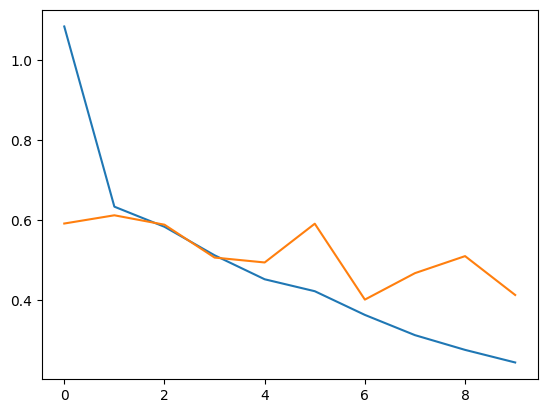

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Code for hyperparameter tuning (but taking very long time)

In [ ]:
def build_model(trial):
  model = Sequential()

  # Correct input shape for a CNN with 256x256 RGB images
  model.add(Input(shape=(256, 256, 3)))
  model.add(BatchNormalization())

  conv_layers = trial.suggest_int('conv_n_layers',1,10)
  conv_nodes = trial.suggest_int('conv_node',8,256)
  padd = trial.suggest_categorical('padding',['valid','same'])

  for i in range(conv_layers):
    model.add(Conv2D(
        filters=conv_nodes,kernel_size=(3,3),
        padding=padd,
        activation='relu',
        kernel_initializer='he_normal'
        # input_shape should only be specified for the first layer, removed here
    ))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2,2),strides=2,padding=padd))

  model.add(Flatten())

  dense_layer = trial.suggest_int('n_layers',1,10)
  dense_nodes = trial.suggest_int('n_nodes',8,128)
  activation = trial.suggest_categorical('activation',['relu','elu','tanh'])
  kernel_init = trial.suggest_categorical('kernel_init',['he_normal','glorot_normal','he_uniform','glorot_uniform'])
  dropout = trial.suggest_categorical('n_dropout',[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])


  for j in range(dense_layer):
    model.add(Dense(
        units=dense_nodes,
        activation = activation,
        kernel_initializer= kernel_init,
    ))
    model.add(Dropout(dropout))

  model.add(Dense(1,activation='sigmoid'))

  optimizer = trial.suggest_categorical('optimizer',['adam','rmsprop','adadelta'])
  model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

  model.summary()

  return model

In [ ]:
def objective(trial):

  keras.backend.clear_session()

  # input_dim parameter is removed as build_model now handles the input shape directly
  model = build_model(trial)

  batch_size = trial.suggest_categorical('batch_size',[50,75,100,125,150])
  history = model.fit(
      train_ds,
      epochs=10,
      batch_size=batch_size,
      validation_data=validation_ds
  )

  val_accuracy = max(history.history['val_accuracy'])
  return val_accuracy

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)

print('best params are')
print(' validation accuracy: ',study.best_values)
print(' best hyperparameter: ')

for k,v in study.best_params.items():
  print('{} -> {}'.format(k,v))

[I 2026-01-06 08:13:41,101] A new study created in memory with name: no-name-0c9bb212-6efa-4d3e-af2b-6813b3b8ed7c


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 256, 256, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 18)   │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 254, 254, 18)   │            72 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 18)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 18)   │         2,934 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 125, 125, 18)   │            72 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 18)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 69192)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 111)            │     7,680,423 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 111)            │        12,432 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,796,017 (29.74 MB)

 Trainable params: 7,795,939 (29.74 MB)

...

 Trainable params: 1,305,982 (4.98 MB)

 Non-trainable params: 2,294 (8.96 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 371ms/step - accuracy: 0.4954 - loss: 1.2924 - val_accuracy: 0.4730 - val_loss: 0.6951
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 353ms/step - accuracy: 0.5002 - loss: 0.7035 - val_accuracy: 0.4956 - val_loss: 0.6933
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 352ms/step - accuracy: 0.4926 - loss: 0.6957 - val_accuracy: 0.5058 - val_loss: 0.6930
Epoch 4/10
325/625 ━━━━━━━━━━━━━━━━━━━━ 1:40 336ms/step - accuracy: 0.4978 - loss: 0.6943

[W 2026-01-06 08:33:58,626] Trial 1 failed with parameters: {'conv_n_layers': 8, 'conv_node': 143, 'padding': 'same', 'n_layers': 6, 'n_nodes': 33, 'activation': 'tanh', 'kernel_init': 'he_uniform', 'n_dropout': 0.9, 'optimizer': 'rmsprop', 'batch_size': 75} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-1780412036.py", line 9, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 377, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

KeyboardInterrupt: 